# **Homework 3**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

**Assignment Number & Name:** HW03_KNN

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## **1. Load the “breast-cancer-wisconsin.data.csv” into Python**

In [31]:
# Loading the dataset
features_domain = [
    'Sample code number', 'Clump Thickness', 'Uniformity of Cell Size','Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
    'Normal Nucleoli', 'Mitoses', 'Class']
df = pd.read_csv('drive/MyDrive/breast-cancer-wisconsin.csv',header=0,names=features_domain)
df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [32]:
df.isnull().sum()

,0
Sample code number,0
Clump Thickness,0
Uniformity of Cell Size,0
Uniformity of Cell Shape,0
Marginal Adhesion,0
Single Epithelial Cell Size,0
Bare Nuclei,0
Bland Chromatin,0
Normal Nucleoli,0
Mitoses,0


In [34]:
df.replace('?', np.nan, inplace=True)
original_count = df.shape[0]
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
feature_cols = df.columns[1:-1]  # All features except ID and Class
df[feature_cols] = df[feature_cols].apply(pd.to_numeric)
df[feature_cols].describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [35]:
# Map class values 2 for benign, 4 for malignant to binary 0 and 1
df['Class_Binary'] = df['Class'].map({2: 0, 4: 1})

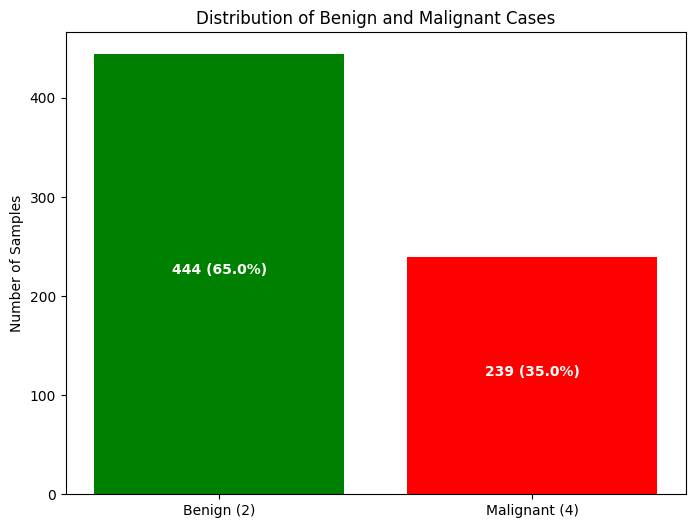

In [36]:
# Class distribution visualization
plt.figure(figsize=(8, 6))
diagnosis_dist = df['Class'].value_counts().sort_index()
plt.bar(['Benign (2)', 'Malignant (4)'], [diagnosis_dist[2], diagnosis_dist[4]], color=['green', 'red'])
plt.title('Distribution of Benign and Malignant Cases')
plt.ylabel('Number of Samples')
plt.text(0, diagnosis_dist[2]/2, f"{diagnosis_dist[2]} ({diagnosis_dist[2]/df.shape[0]:.1%})",
         ha='center', color='white', fontweight='bold')
plt.text(1, diagnosis_dist[4]/2, f"{diagnosis_dist[4]} ({diagnosis_dist[4]/df.shape[0]:.1%})",
         ha='center', color='white', fontweight='bold')
plt.show()

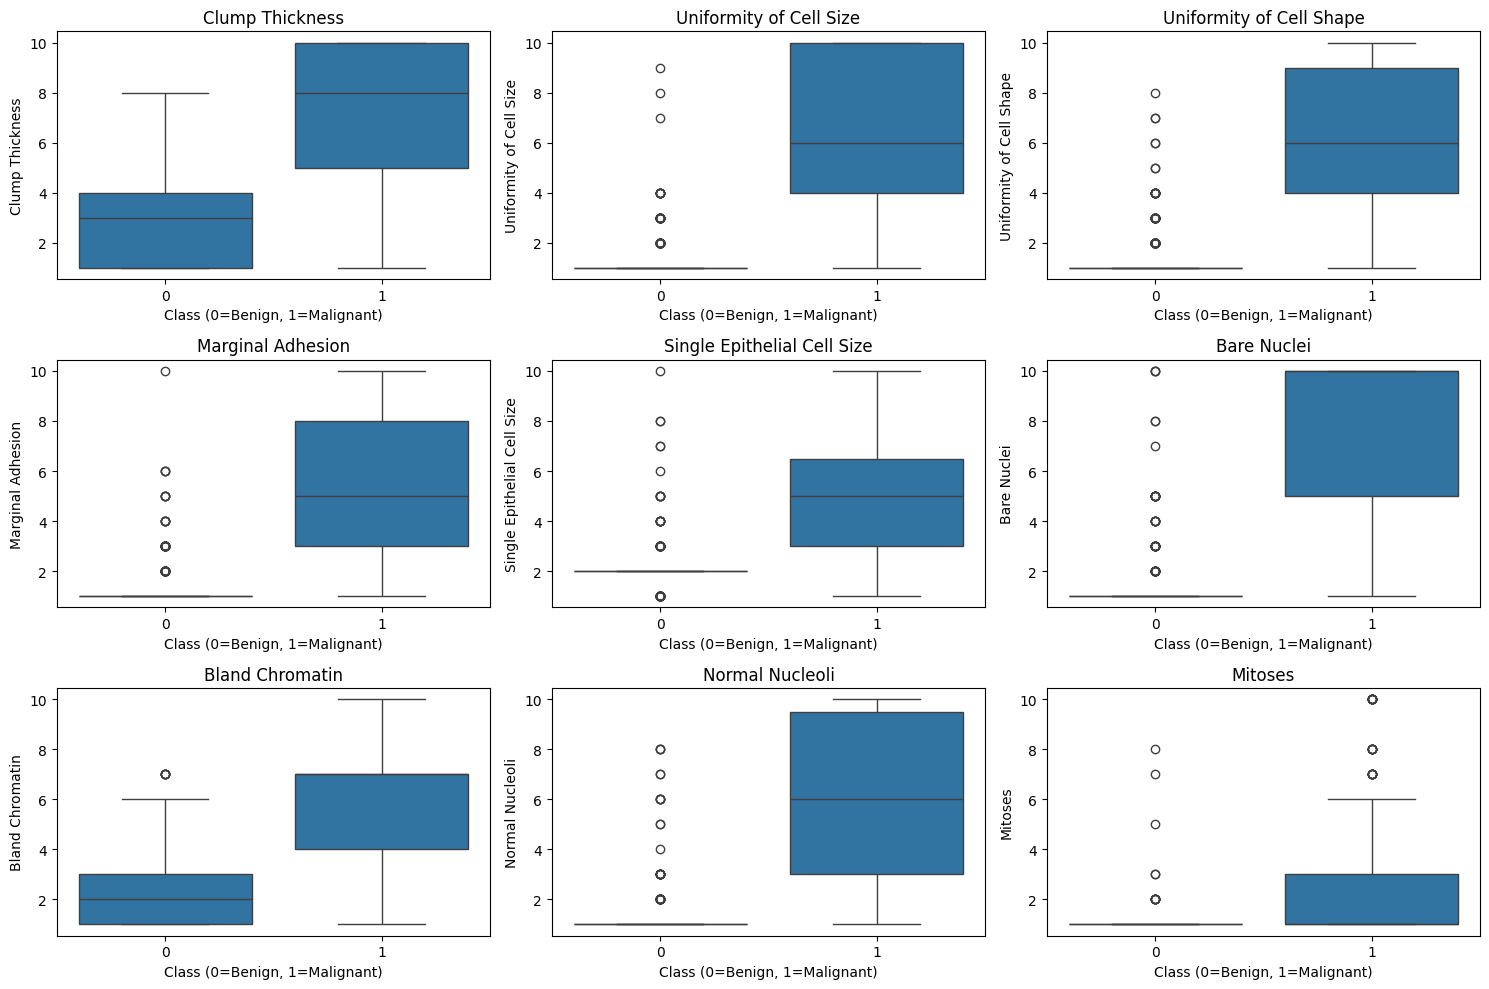

In [38]:
# Visualize feature distributions by class
plt.figure(figsize=(15, 10))
for i, feature in enumerate(feature_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Class_Binary', y=feature, data=df)
    plt.title(feature)
    plt.xlabel('Class (0=Benign, 1=Malignant)')
plt.tight_layout()
plt.show()

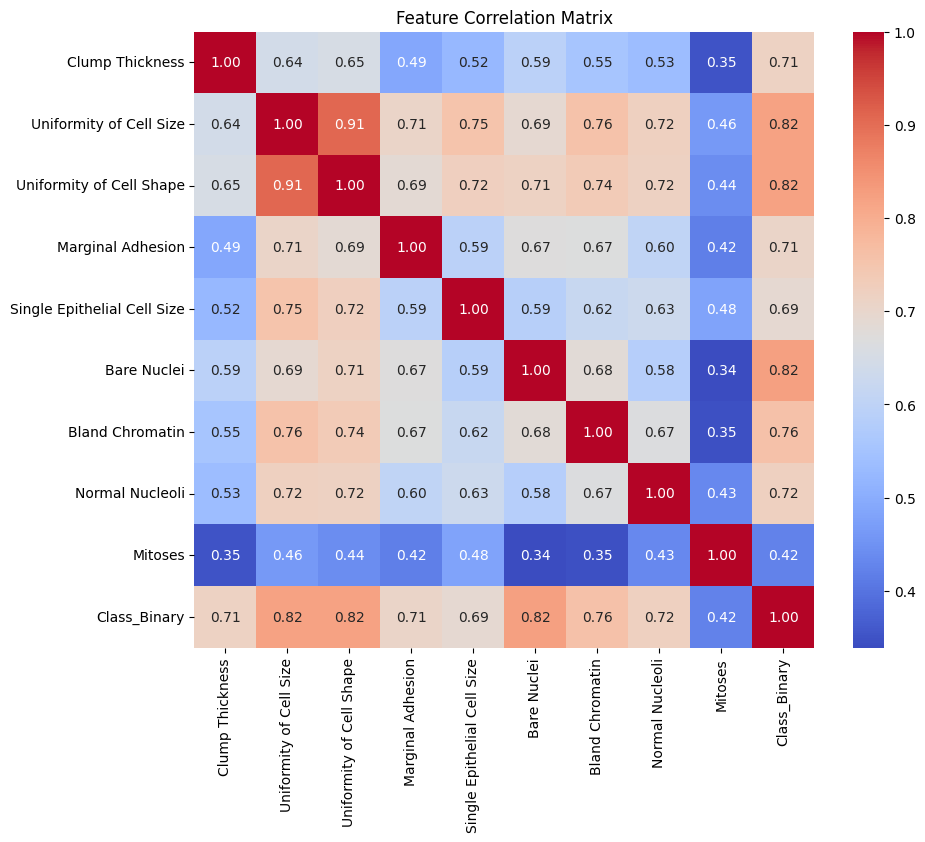

In [39]:
# Correlation matrix to understand feature relationships
plt.figure(figsize=(10, 8))
correlation = df[list(feature_cols) + ['Class_Binary']].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [40]:
# Insights from correlation matrix
correlated_pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        corr_value = correlation.iloc[i, j]
        if abs(corr_value) > 0.7:  # Threshold for high correlation
            correlated_pairs.append((feature_cols[i], feature_cols[j], corr_value))

In [41]:
for f1, f2, corr in correlated_pairs:
    print(f"{f1} and {f2}: {corr:.2f}")

Uniformity of Cell Size and Uniformity of Cell Shape: 0.91
Uniformity of Cell Size and Marginal Adhesion: 0.71
Uniformity of Cell Size and Single Epithelial Cell Size: 0.75
Uniformity of Cell Size and Bland Chromatin: 0.76
Uniformity of Cell Size and Normal Nucleoli: 0.72
Uniformity of Cell Shape and Single Epithelial Cell Size: 0.72
Uniformity of Cell Shape and Bare Nuclei: 0.71
Uniformity of Cell Shape and Bland Chromatin: 0.74
Uniformity of Cell Shape and Normal Nucleoli: 0.72


In [43]:
# Identify features with highest correlation to Class
class_corr = correlation['Class_Binary'].drop('Class_Binary').sort_values(ascending=False)
print("Features most correlated with Class (malignancy):")
for feature, corr in class_corr.items():
    print(f"{feature}: {corr:.2f}")

Features most correlated with Class (malignancy):
Bare Nuclei: 0.82
Uniformity of Cell Shape: 0.82
Uniformity of Cell Size: 0.82
Bland Chromatin: 0.76
Normal Nucleoli: 0.72
Clump Thickness: 0.71
Marginal Adhesion: 0.71
Single Epithelial Cell Size: 0.69
Mitoses: 0.42
